This is a linear regression model that predicts ev charging demand (energy_sold_kwh)

In [1]:
#importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
#loading charging data
df = pd.read_csv("ev_charging_data.csv")

In [3]:
df.head()

,session_id,datetime,hour,day_of_week,is_weekend,temperature,wholesale_price,retail_price,charging_sessions,energy_per_session,energy_sold_kwh
0,1,2025-01-01 00:00:00,0,2,0,25.127134,0.188319,0.235398,5,13.923257,69.616286
1,2,2025-01-01 01:00:00,1,2,0,25.190453,0.182241,0.227801,3,25.697249,77.091747
2,3,2025-01-01 02:00:00,2,2,0,27.573437,0.206828,0.258534,1,25.714565,25.714565
3,4,2025-01-01 03:00:00,3,2,0,28.977748,0.198582,0.248228,2,20.320314,40.640627
4,5,2025-01-01 04:00:00,4,2,0,28.294179,0.208094,0.260118,2,24.234807,48.469613


Feature Selection

In [4]:
#first drop dataetime and session_id as they have no effect on energy sold
model_df = df.drop(columns= ['datetime', 'session_id'])

Heat map to see colums that has high correlation with the demand (energy_sold_kwh)

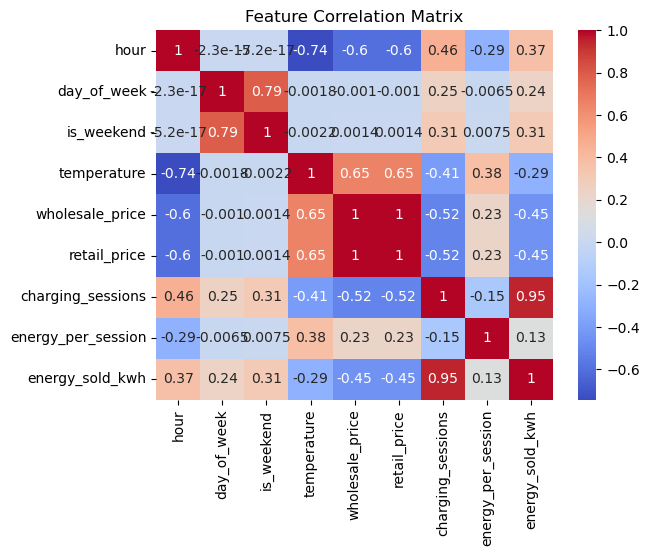

In [5]:
plt.figure()
sns.heatmap(model_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

Multicollinearity can be observed between wholesale_price and retail_price, so whole_sale price will be dropped

In [6]:
model_df = model_df.drop(columns= 'wholesale_price')

Then select the columns with the 5 best correlation as features

In [7]:
features = ['hour', 'is_weekend', 'temperature', 'retail_price', 'charging_sessions']
X = model_df[features]  
y = model_df['energy_sold_kwh']

Train Test Split

In [8]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("----------------------")
print(f'number of rows used in training model: {len(X_train)}')
print(f'number of rows for testing: {len(X_test)}')

----------------------
number of rows used in training model: 2304
number of rows for testing: 576


initialise linear model

In [9]:
model = LinearRegression()

In [10]:
#train model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#predict demand (energy_sold_kwh)
df["predicted_energy_sold_kwh"] = model.predict(X)

Model Evaluation

In [12]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 13.81203656655622
R²: 0.9179291472309605


Feature Importance

In [13]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coefficients)

             Feature  Coefficient
0               hour     0.004691
1         is_weekend     0.690922
2        temperature     2.322162
3       retail_price   -32.839238
4  charging_sessions    21.768236


The regression coefficients indicate that charging demand (energy_sold_kwh) is primarily influenced by temporal patterns such as hour of day and weekend indicators, while retail electricity prices have a negative effect on demand due to price sensitivity.

Saving Model

In [14]:
import joblib

joblib.dump(model, "demand_model.pkl")

['demand_model.pkl']

Predicted vs actual demand

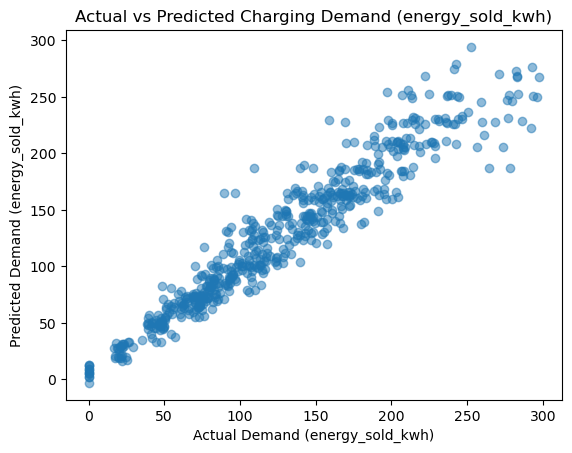

In [15]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Demand (energy_sold_kwh)")
plt.ylabel("Predicted Demand (energy_sold_kwh)")
plt.title("Actual vs Predicted Charging Demand (energy_sold_kwh)")
plt.show()

In [17]:
df.to_csv('model.csv', index = False)